### Description
This notebook serves as a central place to experiment with GPKoopman class features in a local definition envrionment before placing said features into the actual package itself.

#### Package import

In [1]:
import GPKoopman as gpk
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from mpl_toolkits.mplot3d import Axes3D
from IPython.display import display, clear_output
import math
import time

#### Local Class Definition

##### Kernels

In [2]:
def GaussianKernel(X1, X2, hp1, hp2):
    dists = torch.cdist(X1.T, X2.T, p=2)**2
    return hp1 * torch.exp(-dists / (2 * hp2**2))


def ThinSplineKernel(X1, X2, hp1, hp2):
    dists = torch.cdist(X1.T, X2.T, p=2)
    epsilon = 1e-8
    return hp1 * ((dists/hp2)**2) * torch.log((dists / hp2) + epsilon)


def InverseQuadraticKernel(X1, X2, hp1, hp2):
    dists = torch.cdist(X1.T, X2.T, p=2)**2
    return hp1 * (1 / (1 + (dists / (hp2**2))))


def CosineKernel(X1, X2, hp1, hp2):
    dists = torch.cdist(X1.T, X2.T, p=2)
    return hp1 * torch.cos(math.pi * dists / hp2) ** 2


def ExpSineSqrKernel(X1, X2, hp1, hp2):
    dists = torch.cdist(X1.T, X2.T, p=2)
    hp2 = torch.clamp(hp2, min=1e-2)
    epsilon = 1e-4
    return hp1 * torch.exp(epsilon - 0.5 * ((torch.sin(math.pi * dists / hp1)) ** 2) / hp2)
    # return torch.exp((-2 * (torch.sin(math.pi * dists / hp1))**2) / hp2**2)


# Dictionary mapping kernel names to functions
KERNEL_FUNCTIONS = {
    'Gaussian': GaussianKernel,
    'ThinSpline': ThinSplineKernel,
    'InverseQuadratic': InverseQuadraticKernel,
    'ExpSineSqr': ExpSineSqrKernel,
    'Cosine': CosineKernel
}


def KernelFunction(X1, X2=None, kernel_types=['Gaussian'], hp1_list=None, hp2_list=None, combination='sum'):
    """
    Computes a kernel matrix using a combination of multiple kernels.

    Args:
        X1 (Tensor): First set of points.
        X2 (Tensor, optional): Second set of points. Defaults to None.
        kernel_types (list): List of kernel function names.
        hp1_list (list, optional): List of first hyperparameters corresponding to each kernel. Defaults to None.
        hp2_list (list, optional): List of second hyperparameters corresponding to each kernel. Defaults to None.
        combination (str): How to combine kernels ('sum' or 'product'). Defaults to 'sum'.

    Returns:
        Tensor: Kernel matrix.
    """
    if not torch.is_tensor(X1):
        raise TypeError(f"Expected X1 to be a torch.Tensor, but got {
                        type(X1).__name__}.")

    n1 = X1.shape[0]
    if X2 is not None:
        if not torch.is_tensor(X2):
            raise TypeError(f"Expected X2 to be a torch.Tensor, but got {
                            type(X2).__name__}.")
        n2 = X2.shape[0]
        if n1 != n2:
            raise ValueError(
                f'Mismatch in input dimensions. Tensor 1 and 2 have different rows: {n1}, {n2}.')
    else:
        X2 = torch.zeros(n1, 1)

    l1, l2 = X1.shape[1], X2.shape[1]

    cuda0 = torch.device('cuda:0')
    X1, X2 = X1.to(cuda0), X2.to(cuda0)

    # Ensure hyperparameters are lists and match the number of kernels
    if hp1_list is None:
        hp1_list = [torch.tensor(1.0, device=cuda0)] * len(kernel_types)
    if hp2_list is None:
        hp2_list = [torch.tensor(1.0, device=cuda0)] * len(kernel_types)

    if len(hp1_list) != len(kernel_types) or len(hp2_list) != len(kernel_types):
        raise ValueError(
            "Number of hyperparameters must match the number of kernel types.")

    # Compute combined kernel
    if combination == 'sum':
        K = sum(KERNEL_FUNCTIONS[kernel](X1, X2, hp1, hp2)
                for kernel, hp1, hp2 in zip(kernel_types, hp1_list, hp2_list))
    elif combination == 'product':
        K = torch.ones((l1, l2), device=cuda0)  # Initialize product kernel
        for kernel, hp1, hp2 in zip(kernel_types, hp1_list, hp2_list):
            K *= KERNEL_FUNCTIONS[kernel](X1, X2, hp1, hp2)
    else:
        raise ValueError(
            "Invalid combination method. Choose 'sum' or 'product'.")

    return K


##### Class Defs

In [3]:
class GPObservable:
    count = 0

    def __init__(self, d, ns, m=200, kernel_types=['Gaussian'], hp1_list=None, hp2_list=None,
                 noise=2e-8, combination='sum', device='cuda:0'):
        """
        Gaussian Process Observable with customizable kernel functions.

        Args:
            d (int): Dimensionality of the inputs.
            ns (int): Number of training samples.
            kernel_types (list): List of kernel names.
            hp1_list (list): List of first hyperparameters for each kernel.
            hp2_list (list): List of second hyperparameters for each kernel.
            noise (float): Observation noise.
            combination (str): Kernel combination method ('sum' or 'product').
            device (str): Compute device ('cuda:0' or 'cpu').
        """
        self.device = torch.device(device)
        self.kernel_types = kernel_types  # List of kernel functions
        self.combination = combination  # How kernels are combined

        # Ensure hyperparameter lists are set correctly
        self.hp1_list = hp1_list if hp1_list is not None else [torch.tensor(
            1.0, requires_grad=True, device=self.device) for _ in kernel_types]
        self.hp2_list = hp2_list if hp2_list is not None else [torch.tensor(
            1.0, requires_grad=True, device=self.device) for _ in kernel_types]

        if len(self.hp1_list) != len(kernel_types) or len(self.hp2_list) != len(kernel_types):
            raise ValueError(
                "Number of hyperparameters must match the number of kernel types.")

        self.noise = torch.tensor(
            noise, requires_grad=True, device=self.device)
        self.m = min(m,ns)
        #self.idx_SOR = torch.linspace(0, ns-1, m).int()
        self.idx_SOR = torch.linspace(0, ns-1, m).int()
        self.Xm = torch.empty((m,m), device=self.device)
        self.Knm = torch.empty((ns,m), device=self.device)
        self.y = torch.empty((ns, 1), device=self.device)  # Target values
        self.aSOR = torch.empty((ns, 1), device=self.device)    # SOR trained coefficient
        GPObservable.count += 1

    def set_hyperparameters(self, hp1_list=None, hp2_list=None):
        if hp1_list is not None:
            self.hp1_list = [torch.tensor(
                hp, requires_grad=True, device=self.device) for hp in hp1_list]
        if hp2_list is not None:
            self.hp2_list = [torch.tensor(
                hp, requires_grad=True, device=self.device) for hp in hp2_list]

    def trainGP(self, Xtrain, ytrain):
        Xtrain = Xtrain.to(self.device)
        ytrain = ytrain.to(self.device)
        self.Xtrain = Xtrain
        self.y = ytrain

        self.Xm = Xtrain[:, self.idx_SOR]
        
        self.Kmm = KernelFunction(self.Xm, self.Xm, kernel_types=self.kernel_types,
                                  hp1_list=self.hp1_list, hp2_list=self.hp2_list,
                                  combination=self.combination)
        self.Kmn = KernelFunction(self.Xm, self.Xtrain, kernel_types=self.kernel_types,
                                  hp1_list=self.hp1_list, hp2_list=self.hp2_list,
                                  combination=self.combination)

        try:
            L = torch.linalg.cholesky( (self.Kmn @ self.Kmn.T) + ((self.noise)**2)*self.Kmm )
            self.invKmm = torch.cholesky_inverse(L)
        except RuntimeError:
            U, S, V = torch.linalg.svd( (self.Kmn @ self.Kmn.T) + ((self.noise)**2)*self.Kmm )
            S_inv = torch.diag(torch.where(
                S > 1e-6, 1.0 / S, torch.tensor(0.0, device=self.device)))
            self.invKmm = V.T @ S_inv @ U.T
        
        self.alpha = self.invKmm @ self.Kmn @ self.y

    def predictGP(self, Xq):
        Kqm = KernelFunction(Xq, self.Xm, kernel_types=self.kernel_types,
                             hp1_list=self.hp1_list, hp2_list=self.hp2_list,
                             combination=self.combination)
        # Kqq = KernelFunction(Xq, Xq, kernel_types=self.kernel_types,
        #                      hp1_list=self.hp1_list, hp2_list=self.hp2_list,
        #                      combination=self.combination)
        mean = Kqm @ self.alpha
        CovMat = (Kqm @ self.invKmm @ torch.t(Kqm) ) * (self.noise ** 2)
        return mean, CovMat

    def predictMean(self, Xq):
        Kqm = KernelFunction(Xq, self.Xm, kernel_types=self.kernel_types,
                             hp1_list=self.hp1_list, hp2_list=self.hp2_list,
                             combination=self.combination)
        return Kqm @ self.alpha

    def predictCov(self, Xq):
        Kqm = KernelFunction(Xq, self.Xm, kernel_types=self.kernel_types,
                             hp1_list=self.hp1_list, hp2_list=self.hp2_list,
                             combination=self.combination)
        # Kqq = KernelFunction(Xq, Xq, kernel_types=self.kernel_types,
        #                      hp1_list=self.hp1_list, hp2_list=self.hp2_list,
        #                      combination=self.combination)
        return (Kqm @ self.invKmm @ torch.t(Kqm)) * (self.noise ** 2)

    def optimize_hyperparameters(self, max_iter=100, lr=0.01):
        if not hasattr(self, 'Xtrain') or not hasattr(self, 'y'):
            raise ValueError(
                "Training data not found. Please call trainGP before optimizing hyperparameters.")

        self.hp1_list = [hp.detach().requires_grad_() for hp in self.hp1_list]
        self.hp2_list = [hp.detach().requires_grad_() for hp in self.hp2_list]
        self.noise = self.noise.detach().requires_grad_()

        optimizer = torch.optim.Adam(
            self.hp1_list + self.hp2_list + [self.noise], lr=lr)

        for _ in range(max_iter):
            optimizer.zero_grad()
            
            iKmm = torch.linalg.inv(KernelFunction(self.Xm, self.Xm, kernel_types=self.kernel_types,
                                 hp1_list=self.hp1_list, hp2_list=self.hp2_list,
                                 combination=self.combination))
            Kmn = KernelFunction(self.Xm, self.Xtrain, kernel_types=self.kernel_types,
                                 hp1_list=self.hp1_list, hp2_list=self.hp2_list,
                                 combination=self.combination)
            
            K_til = Kmn.T @ iKmm @ Kmn
            K_til += (self.noise**2) * \
                torch.eye(K_til.shape[0], device=self.device)

            invK_til = torch.linalg.inv(K_til)
            y = self.y
            log_det = torch.logdet(K_til)
            ll = -0.5 * (y.t() @ invK_til @ y + log_det +
                         y.shape[0] * torch.log(torch.tensor(2 * torch.pi)))

            loss = -ll.squeeze()
            loss.backward()
            optimizer.step()

        # Update with optimized hyperparameters
        self.trainGP(self.Xtrain, self.y)

    @classmethod
    def count_Observables(cls):
        return cls.count


class GPObservablesManager:
    def __init__(self):
        self.observables = {}

    def add_observable(self, index, d, ns, kernel_types=['Gaussian'], hp1_list=None, hp2_list=None, noise=2e-6, combination='sum'):
        if index in self.observables:
            raise ValueError(f'Observable with index {index} already exists.')
        self.observables[index] = GPObservable(
            d, ns, kernel_types, hp1_list, hp2_list, noise, combination)

    def set_random_hyperparameters(self, seed=42, scale=1.0):
        """
        Assigns random hyperparameters (hp1 and hp2) to all observables.

        Args:
            seed (int): Seed for reproducibility.
            scale (float): Scaling factor for the generated hyperparameters.
        """
        torch.manual_seed(seed)  # Set random seed for reproducibility

        for obs in self.observables.values():
            num_kernels = len(obs.kernel_types)

            # Assign random values to hp1 and hp2 lists
            obs.hp1_list = [
                scale * torch.rand(1, device=obs.device, requires_grad=True) for _ in range(num_kernels)]
            obs.hp2_list = [
                scale * torch.rand(1, device=obs.device, requires_grad=True) for _ in range(num_kernels)]

    def train_observable(self, index, Xtrain, ytrain):
        if index not in self.observables:
            raise ValueError(f'Observable with index {index} does not exist.')
        self.observables[index].trainGP(Xtrain, ytrain)

    def predict_mean(self, index, Xq):
        if index not in self.observables:
            raise ValueError(f'Observable with index {index} does not exist.')
        return self.observables[index].predictMean(Xq)

    def predict_covariance(self, index, Xq):
        if index not in self.observables:
            raise ValueError(f'Observable with index {index} does not exist.')
        return self.observables[index].predictCov(Xq)

    def optimize_hyperparameters(self, max_iter=100, lr=0.01):
        for obs in self.observables.values():
            obs.optimize_hyperparameters(max_iter, lr)

    def get_params(self, index):
        if index not in self.observables:
            raise ValueError(f'Observable with index {index} does not exist.')
        return torch.tensor(self.observables[index].hp1_list + self.observables[index].hp2_list)

    def get_all_params(self):
        if not self.observables:
            raise ValueError('No observables available in manager.')
        return torch.vstack([self.get_params(idx) for idx in self.observables])

    def visualize2D(self, resolution=50, range_x=(-1, 1), range_y=(-1, 1)):
        """
        Generate surface plots for all 2D observables in the manager.

        Args:
            resolution (int): Number of points along each axis for the grid.
            range_x (tuple): Range of values for the first input dimension (min, max).
            range_y (tuple): Range of values for the second input dimension (min, max).
        """
        for idx, observable in self.observables.items():
            # Check if the observable input dimension is 2
            if observable.Xtrain.shape[0] != 2:
                raise ValueError(
                    f"Observable {idx} does not have 2D inputs and cannot be plotted.")

            # Create a meshgrid for plotting
            x = np.linspace(*range_x, resolution)
            y = np.linspace(*range_y, resolution)
            X, Y = np.meshgrid(x, y)
            grid_points = torch.tensor(
                np.vstack([X.ravel(), Y.ravel()]), dtype=torch.float32).to(observable.device)

            # Predict the mean values for the grid points
            Z = observable.predictMean(grid_points)
            Z = Z.cpu()
            Z = Z.detach().numpy().reshape(resolution, resolution)

            # Plot the surface
            fig = plt.figure()
            ax = fig.add_subplot(111, projection='3d')
            ax.plot_surface(X, Y, Z, cmap='viridis', edgecolor='k', alpha=0.8)
            ax.set_title(f"Observable {idx+1} Surface Plot")
            ax.set_xlabel("X1")
            ax.set_ylabel("X2")
            ax.set_zlabel("Mean")
            plt.show()


def getKoopman(manager, indices, Xall, nT, stateAug=False):
    """
    Compute Koopman A matrix using the manager for GPObservables.

    Args:
        manager (GPObservablesManager): Manager holding all GPObservable objects.
        indices (list): List of indices for observables to include.
        Xall (torch.Tensor): n x (N+1) matrix of state trajectory.
        nT (float): number of trajectories in training dataset

    Returns:
        A (torch.Tensor): p x p linear state transition matrix.
        C (torch.Tensor): n x p output matrix.
    """

    if not isinstance(manager, GPObservablesManager):
        raise ValueError(
            'Expected argument manager to be object of class GPObservablesManager')

    n = Xall.shape[0]       # dimensionality of original system
    N = (Xall.shape[1])//nT - 1  # Number of time steps in each trajectory
    p = len(indices)        # number of observables

    X = torch.cat([Xall[:, j*(N+1):j*(N+1)+N] for j in range(nT)],
                  dim=1)         # Data matrix from original system
    Xplus = torch.cat([Xall[:, j*(N+1)+1:j*(N+1)+N+1]
                      for j in range(nT)], dim=1)  # Time-shifted data matrix

    M = torch.empty((p, N*nT))
    Mplus = torch.empty((p, N*nT))
    for i in range(p):
        M[i, :] = torch.transpose(manager.predict_mean(i, X), dim0=0, dim1=-1)
        Mplus[i, :] = torch.transpose(
            manager.predict_mean(i, Xplus), dim0=0, dim1=-1)

    if stateAug:
        M = torch.vstack((X, M))
        Mplus = torch.vstack((Xplus, Mplus))

    # Compute C(z) and A(z)
    M_pinv = torch.linalg.pinv(M)
    A = Mplus @ M_pinv

    if stateAug:
        C = torch.zeros((n, n+p))
        for i in range(n):
            C[i, i] = 1.
    else:
        C = X @ M_pinv

    return A, C

#### Testing Cells

Training Time, 2000 Samples, (Exact GP): 0.217707 sec
Training Time, 2000 Samples, (Subset of Regressors GP): 0.029081 sec
Parameter Optimization Time, 2000 Samples, (Exact GP): 9.481233 sec
Parameter Optimization Time, 2000 Samples, (Subset of Regressors GP): 8.263274 sec
Prediction Time, 100 Samples, (Exact GP): 0.000999 sec
Prediction Time, 100 Samples, (Subset of Regressors): 0.000000 sec
Mean Prediction Error: Exact GP: 0.06793764233589172
Mean Prediction Error: Subset of Regressors: 0.06793764233589172
Norm of difference in variance prediction: 0.0


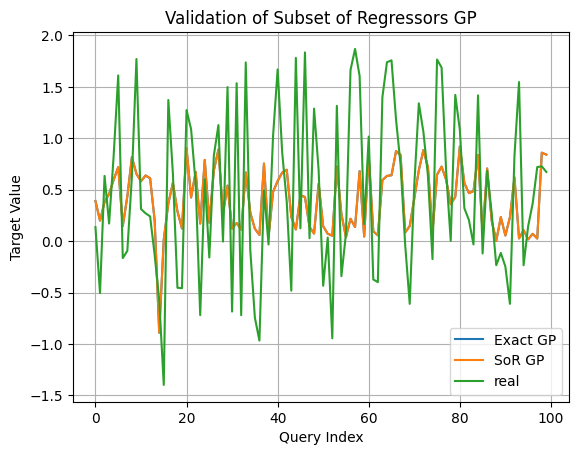

In [4]:
ns=2000
torch.manual_seed(1234)
# Define training data
#Xtrain = torch.randn(2, ns)  # Large dataset with 1000 points

Xtrain = torch.linspace(0.,20.,steps=ns).view(1,ns)
Xtrain = torch.vstack([Xtrain, 2*Xtrain])
ytrain = torch.sin(Xtrain[0,:]) + torch.cos(Xtrain[1,:])

# Initialize GPObservable with SoR
obs0 = gpk.GPObservable(d=2,ns=ns, kernel_types=['Gaussian'])
obs1 = GPObservable(d=2, ns=ns, kernel_types=['Gaussian'], m=200)

# training the 2 GP Observables
start_time = time.time()
obs0.trainGP(Xtrain,ytrain)
train_time0 = time.time() - start_time

start_time = time.time()
obs1.trainGP(Xtrain,ytrain)
train_time1 = time.time() - start_time

# Hyperparameter Optimization
start_time = time.time()
obs0.optimize_hyperparameters(max_iter=200)
opt_time0 = time.time() - start_time

start_time = time.time()
obs1.optimize_hyperparameters(max_iter=200)
opt_time1 = time.time() - start_time

# Query Points
nq = 100
Xq = torch.randn(2,nq)
yreal = torch.sin(Xq[0,:]) + torch.cos(Xq[1,:])

# Preduct Mean
start_time = time.time()
pred_mean0 = obs0.predictMean(Xq)
pred_time0 = time.time() - start_time

start_time = time.time()
pred_mean1 = obs1.predictMean(Xq)
pred_time1 = time.time() - start_time

# Predict Variance
start_time = time.time()
pred_var0 = obs0.predictCov(Xq)
var_time0 = time.time() - start_time

start_time = time.time()
pred_var1 = obs1.predictCov(Xq)
var_time1 = time.time() - start_time

var0 = torch.diag(pred_var0.detach().cpu())
var1 = torch.diag(pred_var1.detach().cpu())

# Mean & Covariance Prediction Errors
enorm_eGP = torch.linalg.norm(yreal - pred_mean0.detach().cpu())/nq
enorm_SOR = torch.linalg.norm(yreal - pred_mean1.detach().cpu())/nq
vdiff = torch.linalg.norm(var0 - var1)/nq

# Timing Results
print(f"Training Time, {ns} Samples, (Exact GP): {train_time0:.6f} sec")
print(f"Training Time, {ns} Samples, (Subset of Regressors GP): {train_time1:.6f} sec")
print(f"Parameter Optimization Time, {ns} Samples, (Exact GP): {opt_time0:.6f} sec")
print(f"Parameter Optimization Time, {ns} Samples, (Subset of Regressors GP): {opt_time1:.6f} sec")
print(f"Prediction Time, {nq} Samples, (Exact GP): {pred_time0:.6f} sec")
print(f"Prediction Time, {nq} Samples, (Subset of Regressors): {pred_time1:.6f} sec")
print(f'Mean Prediction Error: Exact GP: {enorm_eGP}')
print(f'Mean Prediction Error: Subset of Regressors: {enorm_SOR}')
print(f'Norm of difference in variance prediction: {vdiff}')

plt.plot(pred_mean0.detach().cpu(),label='Exact GP')
plt.plot(pred_mean1.detach().cpu(),label='SoR GP')
plt.plot(yreal,label='real')
#plt.plot(ytrain.detach().cpu(),label='Data')
plt.title(f'Validation of Subset of Regressors GP')
plt.grid()
plt.legend()
plt.xlabel('Query Index')
plt.ylabel('Target Value')
plt.show()
